In [ ]:
# packages
%pip install cartopy
%pip install netCDF4
%pip install geopandas

In [ ]:
# download moisture data
# https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/soil_moisture/
import os
import urllib.request as request

MOISTURE_SOIL_TYPE = 'grass'  # 'grass', 'wheat',  'oak','pine','spruce','beach'
BASE_URL = 'https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/soil_moisture'
CACHE_FOLDER = "dwd_data"

def get_moisture_file(year:int=2024, depth_range:str='0-10') -> str:
    
    # download if not in current folder, else return path
    filepath = f"grids_germany_daily_soil_moisture_{MOISTURE_SOIL_TYPE}_{year}_{depth_range}_v1.nc"
    local_storage_path = os.path.join(os.getcwd(), CACHE_FOLDER, filepath)

    if not os.path.exists(local_storage_path):
        url = f"{BASE_URL}/{MOISTURE_SOIL_TYPE}/{year}/{filepath}"
        print(f"Downloading {url} ... (>~130MB)")
        request.urlretrieve(url, local_storage_path)
        print(f"Downloaded to {local_storage_path}")

    return local_storage_path

In [7]:
# Check the moisture file
import netCDF4

YEAR = 2024
DEPTH_RANGE = '0-10'  # '20-30'

nc_file = netCDF4.Dataset(get_moisture_file(YEAR, DEPTH_RANGE), mode='r')

# Print variable names and basic info
for var_name in nc_file.variables:
    var = nc_file.variables[var_name]
    print(f"{var_name}: shape={var.shape}, dtype={var.dtype}, dims={var.dimensions}")
    # Print main attributes if present
    for attr in ['long_name', 'units', 'standard_name', 'scale_factor']:
        if attr in var.ncattrs():
            print(f"  {attr}: {var.getncattr(attr)}")
    print()


time: shape=(366,), dtype=int32, dims=('time',)
  units: days since 2024-01-01

x: shape=(654,), dtype=float64, dims=('x',)
  long_name: x coordinate of projection
  units: m
  standard_name: projection_x_coordinate

y: shape=(866,), dtype=float64, dims=('y',)
  long_name: y coordinate of projection
  units: m
  standard_name: projection_y_coordinate

lyr: shape=(1,), dtype=int64, dims=('lyr',)

paws: shape=(1, 366, 866, 654), dtype=int16, dims=('lyr', 'time', 'y', 'x')
  long_name: Percentage of plant available water content of soil layer
  units: % nFK
  standard_name: percentage_of_plant_available_water_content_of_soil_layer
  scale_factor: 0.1



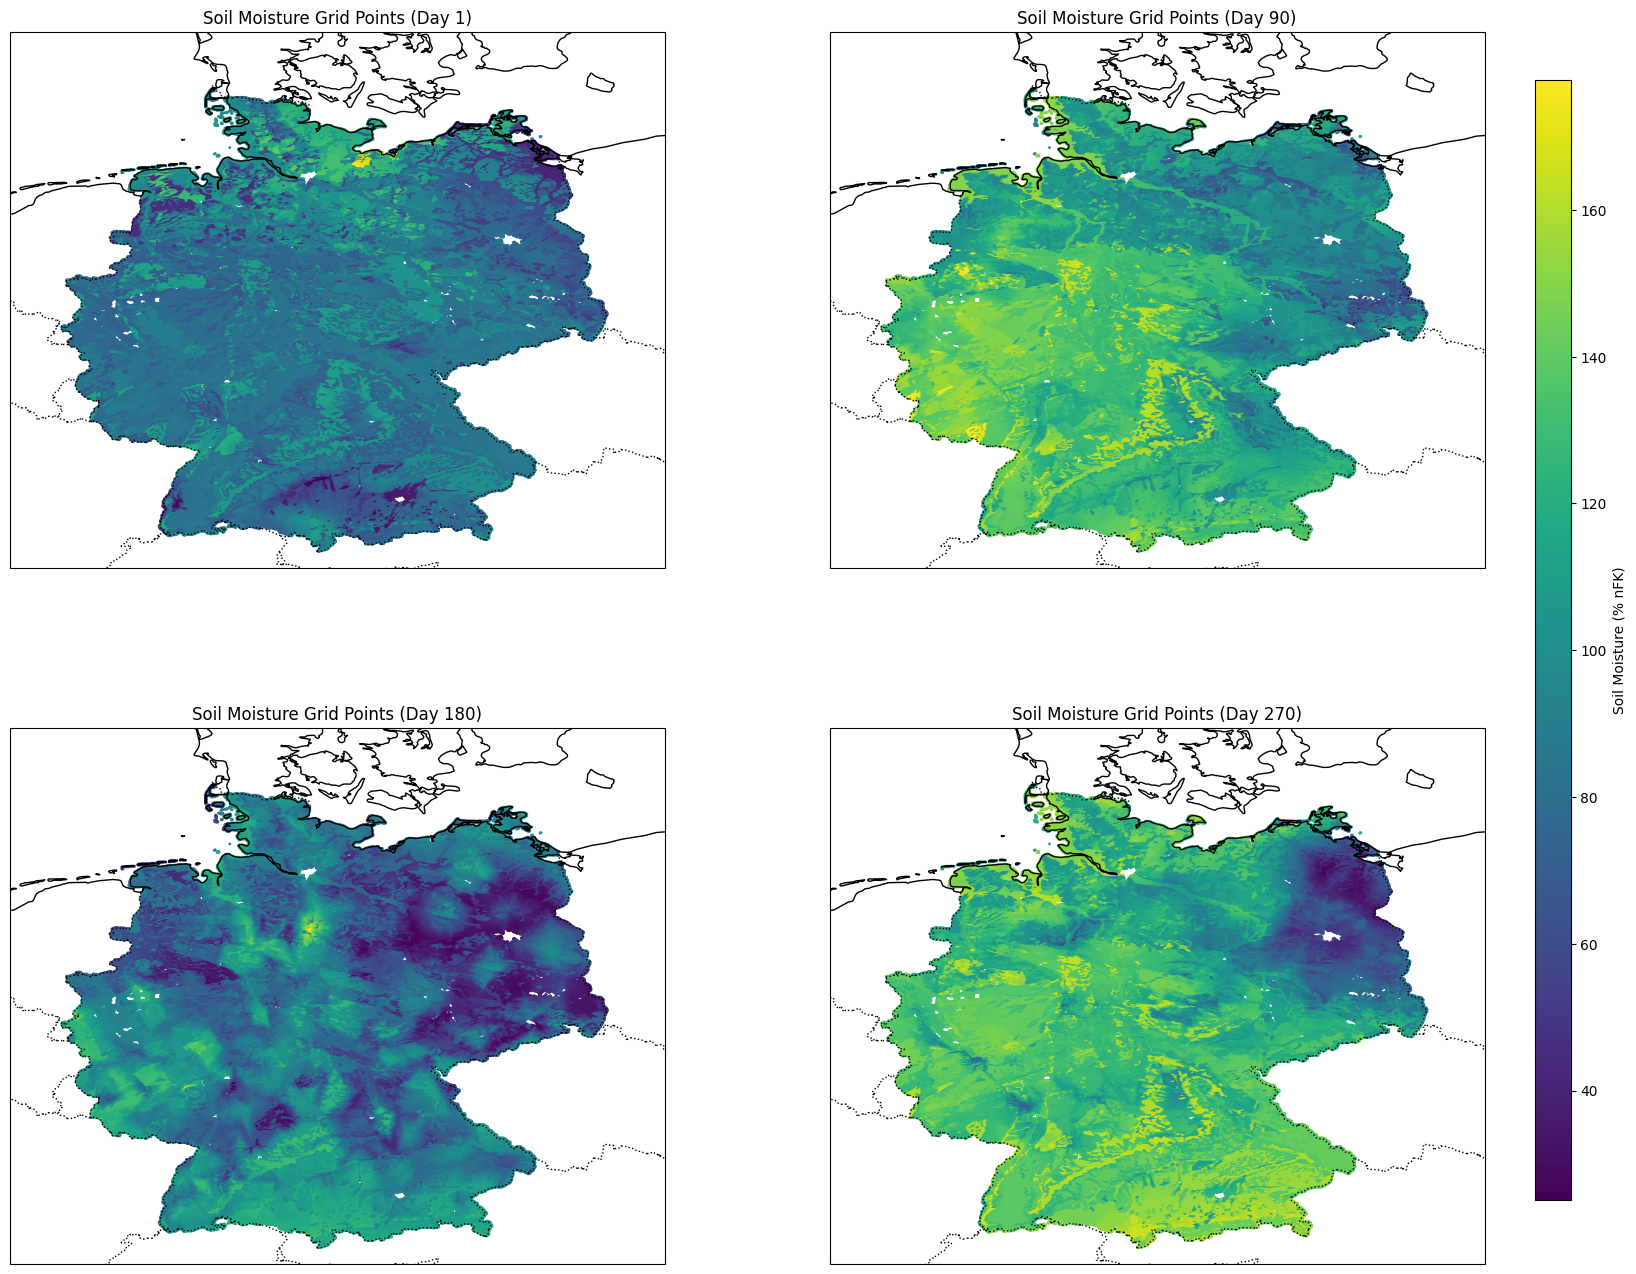

In [10]:
# plot moisture data for 4 different days
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import netCDF4

import cartopy.crs as ccrs
import cartopy.feature as cfeature

YEAR = 2024
DEPTH_RANGE = '0-10'  # '20-30'

nc_file = netCDF4.Dataset(get_moisture_file(YEAR, DEPTH_RANGE), mode='r')

# Create all combinations of x and y coordinates
x_coords = nc_file.variables['x']
y_coords = nc_file.variables['y']
xv, yv = np.meshgrid(x_coords, y_coords)
xv_flat = xv.flatten()
yv_flat = yv.flatten()

# Create GeoDataFrame with all combinations
gdf_all = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(xv_flat, yv_flat),
    crs='EPSG:31467'
)

# Transform to WGS84
gdf_all_wgs84 = gdf_all.to_crs('EPSG:4326')

days = [1, 90, 180, 270]
fig, axs = plt.subplots(2, 2, figsize=(18, 16), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, day in zip(axs.flat, days):
    moisture_data = nc_file.variables['paws'][0, day, :, :]
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([5, 16, 47, 56], crs=ccrs.PlateCarree())
    # Flatten moisture data and mask
    moisture_flat = moisture_data.flatten()
    mask = ~np.ma.getmaskarray(moisture_flat)
    # Only plot valid points
    sc = ax.scatter(
        gdf_all_wgs84.geometry.x[mask],
        gdf_all_wgs84.geometry.y[mask],
        c=moisture_flat[mask],
        s=1,
        cmap='viridis',
        transform=ccrs.PlateCarree()
    )
    ax.set_title(f'Soil Moisture Grid Points (Day {day})')

cax = fig.add_axes([0.98, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coordinates
cbar = fig.colorbar(sc, cax=cax, orientation='vertical', label='Soil Moisture (% nFK)')
plt.subplots_adjust(right=0.96, wspace=0.2, hspace=0.3)
plt.show()



Skipping irrigation for day 122 as only 1.00% nFK needed.
Skipping irrigation for day 123 as only 3.10% nFK needed.
irrigate day 124 with 5.52 mm, evaporation: -2.8 
Skipping irrigation for day 125 as only 3.28% nFK needed.
Skipping irrigation for day 126 as only 4.88% nFK needed.
irrigate day 127 with 7.45 mm, evaporation: -2.6 
Skipping irrigation for day 128 as only 4.42% nFK needed.
Skipping irrigation for day 129 as only 3.02% nFK needed.
irrigate day 130 with 4.71 mm, evaporation: -2.2 
Skipping irrigation for day 131 as only 0.81% nFK needed.
Skipping irrigation for day 132 as only 2.01% nFK needed.
Skipping irrigation for day 133 as only 4.71% nFK needed.
Skipping irrigation for day 159 as only 0.70% nFK needed.
irrigate day 160 with 7.12 mm, evaporation: -6.4 
irrigate day 161 with 7.65 mm, evaporation: -6.9 
irrigate day 162 with 4.92 mm, evaporation: -5.7 
Skipping irrigation for day 164 as only 1.82% nFK needed.
irrigate day 165 with 6.58 mm, evaporation: -6.3 
irrigate day

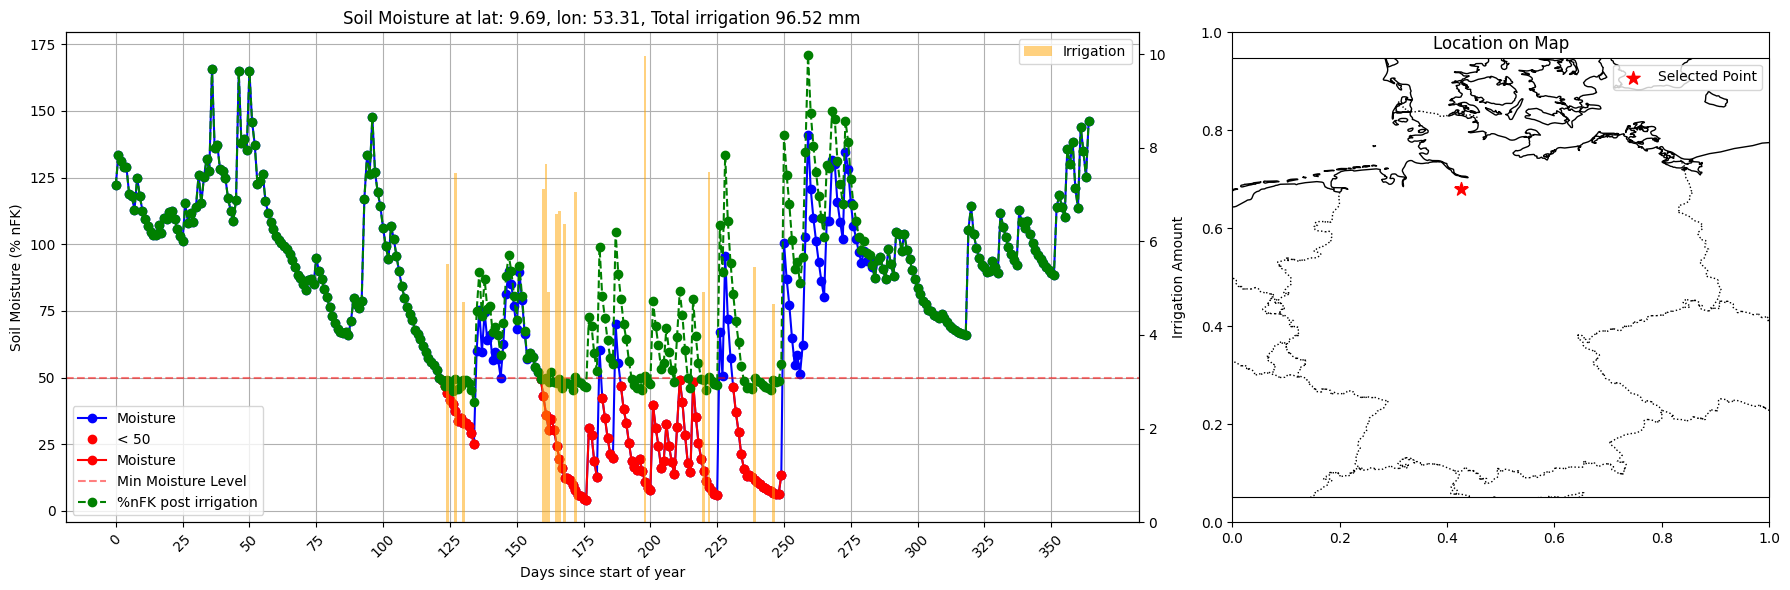

In [ ]:
# plot for a single postion over all days in the year
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import netCDF4
import random
import cartopy.crs as ccrs
import cartopy.feature as cfeature

YEAR = 2022
DEPTH_RANGE = '0-10'  # '20-30'
MIN_MOISTURE_LEVEL = 50  # in % nFK

nc_file = netCDF4.Dataset(get_moisture_file(YEAR, DEPTH_RANGE), mode='r')


def gauss_to_wgs84(x, y):
    """
    Convert Gauss-Krueger coordinates (EPSG:31467) to WGS84 (EPSG:4326).
    """
    point_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([x], [y]),
        crs='EPSG:31467'
    )
    point_wgs84 = point_gdf.to_crs('EPSG:4326')
    return point_wgs84.geometry.x.iloc[0], point_wgs84.geometry.y.iloc[0]


def find_random_coordinate_with_date():
    """
    Get a random x and y coordinate from the netCDF file.
    """
    attempts = 0
    while attempts < 10:
        x_idx = random.randint(0, len(nc_file.variables['x']) - 1)
        y_idx = random.randint(0, len(nc_file.variables['y']) - 1)
        x_val = nc_file.variables['x'][x_idx]
        y_val = nc_file.variables['y'][y_idx]
        moisture_data = nc_file.variables['paws'][0, :, y_idx, x_idx]
        # Check if all values are masked or blank
        if np.ma.is_masked(moisture_data) and moisture_data.mask.all():
            attempts += 1
            continue
        if np.all(moisture_data == nc_file.variables['paws']._FillValue):
            attempts += 1
            continue
        # Found valid data

        # Calculate lat/lon using geopandas
        lat, lon = gauss_to_wgs84(x_val, y_val)

        return lat, lon, moisture_data
    raise ValueError(
        "Could not find a valid coordinate with non-blank moisture data.")


def calculate_precipitation(moisture_data, min_moisture_level=MIN_MOISTURE_LEVEL):

    """ Calculate irrigation needs based on moisture data.
    Args:
        moisture_data (np.ndarray): Array of soil moisture data (% nFK).

        Wir verwenden eine Faustformel: 1mm Bewässerung -> 1% nFK Erhöhung
        
    Returns:
        np.ndarray: New moisture levels after irrigation.
        np.ndarray: Irrigation amounts for each day.
    """

    WEATHER_FORECAST_DAYS = 4  # days in advance for precipitation forecast
    MIN_IRRIGATION_NEEDED = 5  # in % nFK, minimum irrigation needed to trigger irrigation

    new_moisture = [moisture_data[0]] * len(moisture_data)
    irrigation = [0] * len(moisture_data)

    for day in range(len(moisture_data)):
        evaporation = 0
        if day > 0:
            evaporation = moisture_data[day] - moisture_data[day-1] # aus der Zeitreihe
            new_moisture[day] = new_moisture[day-1] + evaporation

        # get moisture data for the day
        if new_moisture[day] < min_moisture_level:
            # Calculate new moisture level after precipitation
            preciption_needed = MIN_MOISTURE_LEVEL - new_moisture[day]

            if preciption_needed < MIN_IRRIGATION_NEEDED:
                print(f"Skipping irrigation for day {day} as only {preciption_needed:.2f}% nFK needed.")
                continue  # Skip if less than 5% nFK needed

            # Wetterbericht geht 4 Tage im Voraus
            upcoming_moisture_levels = moisture_data[day:day + WEATHER_FORECAST_DAYS]
            if not np.any(upcoming_moisture_levels > min_moisture_level) :
                irrigation_needed = preciption_needed * np.random.uniform(0.8, 1.2)
                new_moisture[day] = new_moisture[day] + irrigation_needed
                irrigation[day] = irrigation_needed

                print(f"irrigate day {day} with {irrigation_needed:.2f} mm, evaporation: {evaporation:.1f} " )

            
        
        if new_moisture[day] > moisture_data[day]:
            new_moisture[day] = new_moisture[day] * 0.99
        
        if new_moisture[day] < moisture_data[day]:
           new_moisture[day] = moisture_data[day] 

    return np.array(new_moisture), np.array(irrigation)


lat, lon, moisture_data = find_random_coordinate_with_date()
new_moisture, irrigation = calculate_precipitation(moisture_data)

time_days = nc_file.variables['time'][:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(
    18, 6), gridspec_kw={'width_ratios': [2, 1]})

below_min = moisture_data < MIN_MOISTURE_LEVEL

# Moisture time series plot
moisture_data_plot = moisture_data.copy()
# moisture_data_plot[below_min] = np.nan
ax1.plot(time_days, moisture_data_plot, marker='o',
         linestyle='-', color='b', label='Moisture')
ax1.set_title(f'Soil Moisture at lat: {lat:.2f}, lon: {lon:.2f}, Total irrigation {np.sum(irrigation):.2f} mm')
ax1.set_xlabel('Days since start of year')
ax1.set_ylabel('Soil Moisture (% nFK)')
ax1.grid()
ax1.set_xticks(time_days[::25])
ax1.tick_params(axis='x', rotation=45)


# Highlight below min moisture level
moisture_data_plot = moisture_data.copy()
ax1.plot(time_days[below_min], moisture_data[below_min],
         'ro', label=f'< {MIN_MOISTURE_LEVEL}')
moisture_data_plot[~below_min] = np.nan
ax1.plot(time_days, moisture_data_plot, marker='o',
         linestyle='-', color='r', label='Moisture')
ax1.axhline(MIN_MOISTURE_LEVEL, color='r', linestyle='--',
            alpha=0.5, label='Min Moisture Level')

# add pl

ax1.plot(time_days, new_moisture, marker='o', linestyle='--',
         color='g', label='%nFK post irrigation')
# Plot irrigation as bars on a secondary y-axis
ax1b = ax1.twinx()
ax1b.bar(time_days, irrigation, color='orange', alpha=0.5, label='Irrigation', width=1)
ax1b.set_ylabel('Irrigation Amount')
ax1b.legend(loc='upper right')

ax1.legend()

# Cartopy plot for location
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([5, 16, 47, 56], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.add_feature(cfeature.COASTLINE)
ax2.scatter(lat, lon, color='red', s=100, marker='*',
            transform=ccrs.PlateCarree(), label='Selected Point')
ax2.set_title('Location on Map')
ax2.legend()

plt.tight_layout()
plt.show()